# 📊 Data Analytics Live Project — Cloud Counselage GPI
## **Intern:** Jatin Rathod | **Intern ID:** IP-11635 | **Domain:** Data Analytics
## **Project Title:** Absence of Insights for the Relationship Between Student's Economic Background, Academic Performance, Competence & Expected Salary
---
**Dataset:** `Power_BI_Updated_Data_analyst_Data.xlsx` — 4,894 rows × 16 columns

**Structure:**
1. Setup & Data Loading
2. Data Cleaning & Preprocessing
3. Basic Questions (Q1–Q9) — Attempt any 8
4. Moderate Questions (Q10–Q17) — Attempt any 8


## 📦 Step 1: Install & Import Libraries

In [ ]:
# Install required libraries (only needed in Colab)
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────
BLUE   = '#175F9E'
TEAL   = '#028090'
ORANGE = '#E07B39'
GREEN  = '#2E8B57'
PURPLE = '#6A4C93'
RED    = '#C0392B'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [ ]:
import os
# Check exact filename in Colab
print(os.listdir('/content'))


['.config', 'Power BI Updated Data analyst Data.xlsx', 'sample_data']


## 📂 Step 2: Load Dataset
> Upload `Power_BI_Updated_Data_analyst_Data.xlsx` to Colab before running this cell.

In [ ]:
# Load the dataset
df = pd.read_excel('Power BI Updated Data analyst Data.xlsx')

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(3)

✅ Dataset loaded: 4894 rows × 16 columns
Columns: ['First Name', 'Email ID', 'Quantity', 'Events', 'Attendee Status', 'College Name', 'How did you come to know about this event?', 'Specify in "Others" (how did you come to know about this event)', 'Designation', 'Year of Graduation', 'City', 'CGPA', 'Experience with python (Months)', 'Family Income', 'Expected salary (Lac)', 'Leadership- skills']


,First Name,Email ID,Quantity,Events,Attendee Status,College Name,How did you come to know about this event?,"Specify in ""Others"" (how did you come to know about this event)",Designation,Year of Graduation,City,CGPA,Experience with python (Months),Family Income,Expected salary (Lac),Leadership- skills
0,ANIKET,aniket@xyz.com,1,Art of Resume Building,Attending,D Y PATIL INSTITUTE OF MCA AND MANAGEMENT AKUR...,Email,NaN,Students,2024,Patna,6.7,7,7 Lakh+,6,yes
1,Dhanshree,dhanshree@xyz.com,1,Art of Resume Building,Attending,AP SHAH INSTITUTE OF TECHNOLOGY,Others,College,Students,2024,Amravati,8.2,3,0-2 Lakh,7,no
2,Dhiraj,dhiraj@xyz.com,1,Art of Resume Building,Attending,Don Bosco College of Engineering Fatorda Goa,Email,NaN,Students,2023,Kunrool,6.5,4,5-7 Lakh,7,no


## 🧹 Step 3: Data Cleaning & Preprocessing

In [ ]:
# ── 1. Check nulls ────────────────────────────────────────────────────
print('NULL VALUES PER COLUMN:')
print(df.isnull().sum())

# ── 2. Standardize Leadership Skills column ───────────────────────────
print('\nBefore cleaning Leadership column:', df['Leadership- skills'].unique())
df['Leadership- skills'] = df['Leadership- skills'].str.strip().str.lower()
print('After cleaning:', df['Leadership- skills'].unique())

# ── 3. Create unique-student dataframe (deduplicated on Email ID) ─────
df_unique = df.drop_duplicates(subset='Email ID').reset_index(drop=True)
print(f'\nTotal rows (all event attendances): {len(df)}')
print(f'Unique students (by Email ID):      {len(df_unique)}')

# ── 4. Data types overview ────────────────────────────────────────────
print('\nDATA TYPES:')
print(df.dtypes)

NULL VALUES PER COLUMN:
First Name                                                            0
Email ID                                                              0
Quantity                                                              0
Events                                                                0
Attendee Status                                                       0
College Name                                                         15
How did you come to know about this event?                         2216
Specify in "Others" (how did you come to know about this event)    4805
Designation                                                           0
Year of Graduation                                                    0
City                                                                  0
CGPA                                                                  0
Experience with python (Months)                                       0
Family Income                           

---
# 📘 BASIC QUESTIONS (Attempt any 8)
---

## Q1. How many unique students are included in the dataset?

Total event registrations (rows): 4,894
Unique students (by Email ID):    2,157
Duplicate/repeat attendances:     2,737


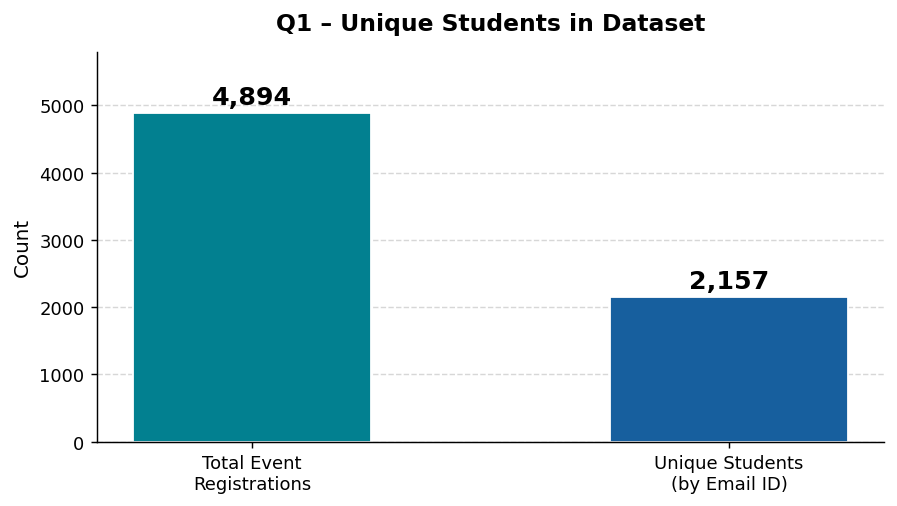


✅ Q1 Answer: There are 2,157 unique students in the dataset.


In [ ]:
q1_unique = df['Email ID'].nunique()
q1_total  = len(df)
print(f'Total event registrations (rows): {q1_total:,}')
print(f'Unique students (by Email ID):    {q1_unique:,}')
print(f'Duplicate/repeat attendances:     {q1_total - q1_unique:,}')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Total Event\nRegistrations', 'Unique Students\n(by Email ID)'],
              [q1_total, q1_unique], color=[TEAL, BLUE], width=0.5, edgecolor='white')
for bar, val in zip(bars, [q1_total, q1_unique]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax.set_title('Q1 – Unique Students in Dataset', pad=12)
ax.set_ylabel('Count')
ax.set_ylim(0, 5800)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q1 Answer: There are 2,157 unique students in the dataset.')

## Q2. What is the average GPA of the students?

Average CGPA (unique students): 8.03
Median  CGPA (unique students): 7.9
Std Dev: 1.00
Min: 6.2, Max: 9.9


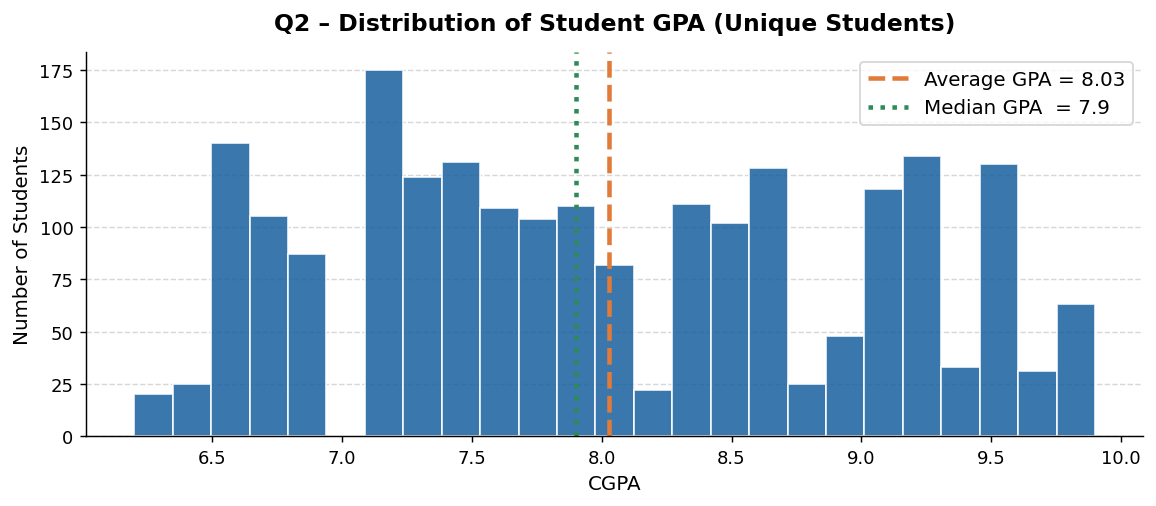


✅ Q2 Answer: The average CGPA of the 2,157 unique students is 8.03.


In [ ]:
avg_gpa = round(df_unique['CGPA'].mean(), 2)
med_gpa = round(df_unique['CGPA'].median(), 2)
print(f'Average CGPA (unique students): {avg_gpa}')
print(f'Median  CGPA (unique students): {med_gpa}')
print(f'Std Dev: {df_unique["CGPA"].std():.2f}')
print(f'Min: {df_unique["CGPA"].min()}, Max: {df_unique["CGPA"].max()}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_unique['CGPA'].dropna(), bins=25, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(avg_gpa, color=ORANGE, linewidth=2.5, linestyle='--', label=f'Average GPA = {avg_gpa}')
ax.axvline(med_gpa, color=GREEN,  linewidth=2.5, linestyle=':',  label=f'Median GPA  = {med_gpa}')
ax.set_title('Q2 – Distribution of Student GPA (Unique Students)', pad=12)
ax.set_xlabel('CGPA')
ax.set_ylabel('Number of Students')
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(f'\n✅ Q2 Answer: The average CGPA of the {len(df_unique):,} unique students is {avg_gpa}.')

## Q3. What is the distribution of students across different graduation years?

Students by Graduation Year:
Year of Graduation
2023    676
2024    679
2025    565
2026    237


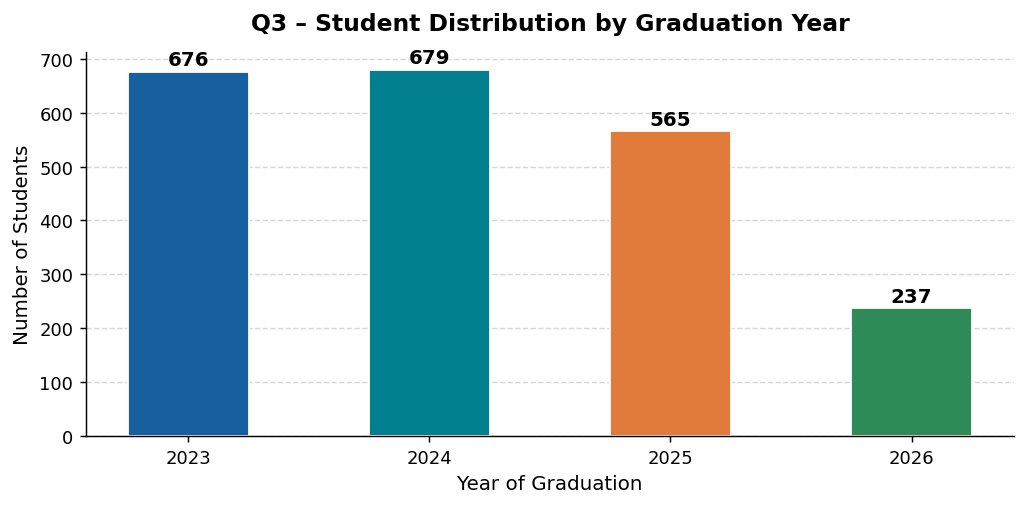


✅ Q3 Answer: Most students (676) graduated in 2023, followed by 2024 (679), 2025 (565), and 2026 (237).


In [ ]:
grad_dist = df_unique['Year of Graduation'].value_counts().sort_index()
print('Students by Graduation Year:')
print(grad_dist.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(grad_dist.index.astype(str), grad_dist.values,
              color=[BLUE, TEAL, ORANGE, GREEN], edgecolor='white', width=0.5)
for bar, val in zip(bars, grad_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Q3 – Student Distribution by Graduation Year', pad=12)
ax.set_xlabel('Year of Graduation')
ax.set_ylabel('Number of Students')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q3 Answer: Most students graduated in 2024 (679), followed by 2023 (676), 2025 (565), and 2026 (237).')

## Q4. What is the distribution of student's experience with Python programming?

Python Experience Distribution (unique students):
Experience with python (Months)
3    434
4    366
5    554
6    171
7    503
8    129

Average Python experience: 5.2 months


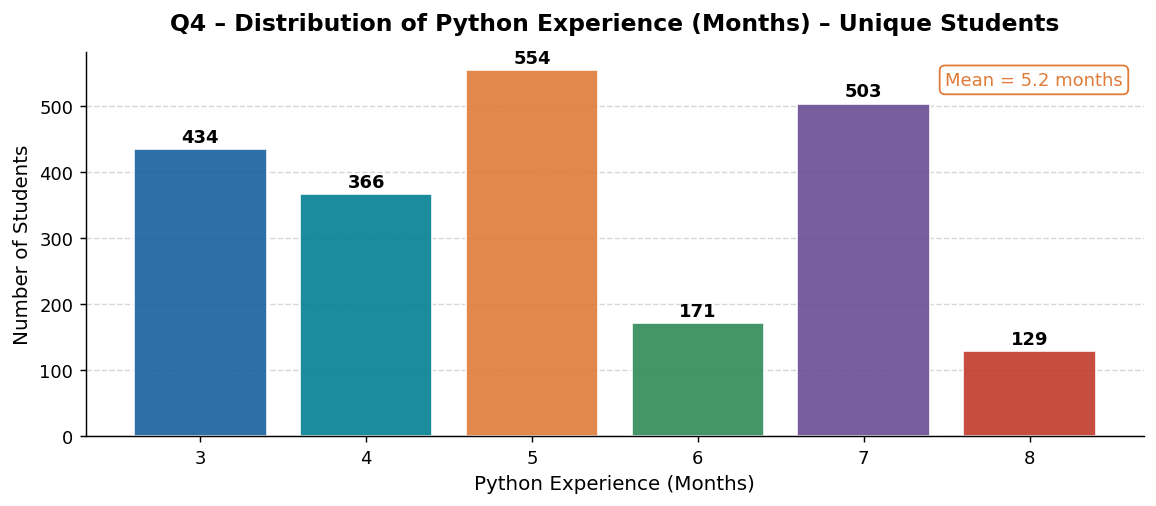


✅ Q4 Answer: Python experience ranges from 3 to 8 months. 5 months is most common (554 students). Average = 5.2 months.


In [ ]:
py_dist = df_unique['Experience with python (Months)'].value_counts().sort_index()
avg_py  = round(df_unique['Experience with python (Months)'].mean(), 1)
print(f'Python Experience Distribution (unique students):')
print(py_dist.to_string())
print(f'\nAverage Python experience: {avg_py} months')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(py_dist.index.astype(str), py_dist.values,
              color=[BLUE, TEAL, ORANGE, GREEN, PURPLE, RED], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, py_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.text(0.98, 0.95, f'Mean = {avg_py} months', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color=ORANGE,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=ORANGE))
ax.set_title('Q4 – Distribution of Python Experience (Months) – Unique Students', pad=12)
ax.set_xlabel('Python Experience (Months)')
ax.set_ylabel('Number of Students')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(f'\n✅ Q4 Answer: Python experience ranges from 3 to 8 months. 5 months is most common (554 students). Average = {avg_py} months.')

## Q5. What is the average family income of the student?

Family Income Distribution (unique students):
  0-2 Lakh: 2000 students (92.7%)
  2-5 Lakh: 85 students (3.9%)
  5-7 Lakh: 31 students (1.4%)
  7 Lakh+: 41 students (1.9%)

Most common bracket: 0-2 Lakh (2000 students, 92.7%)


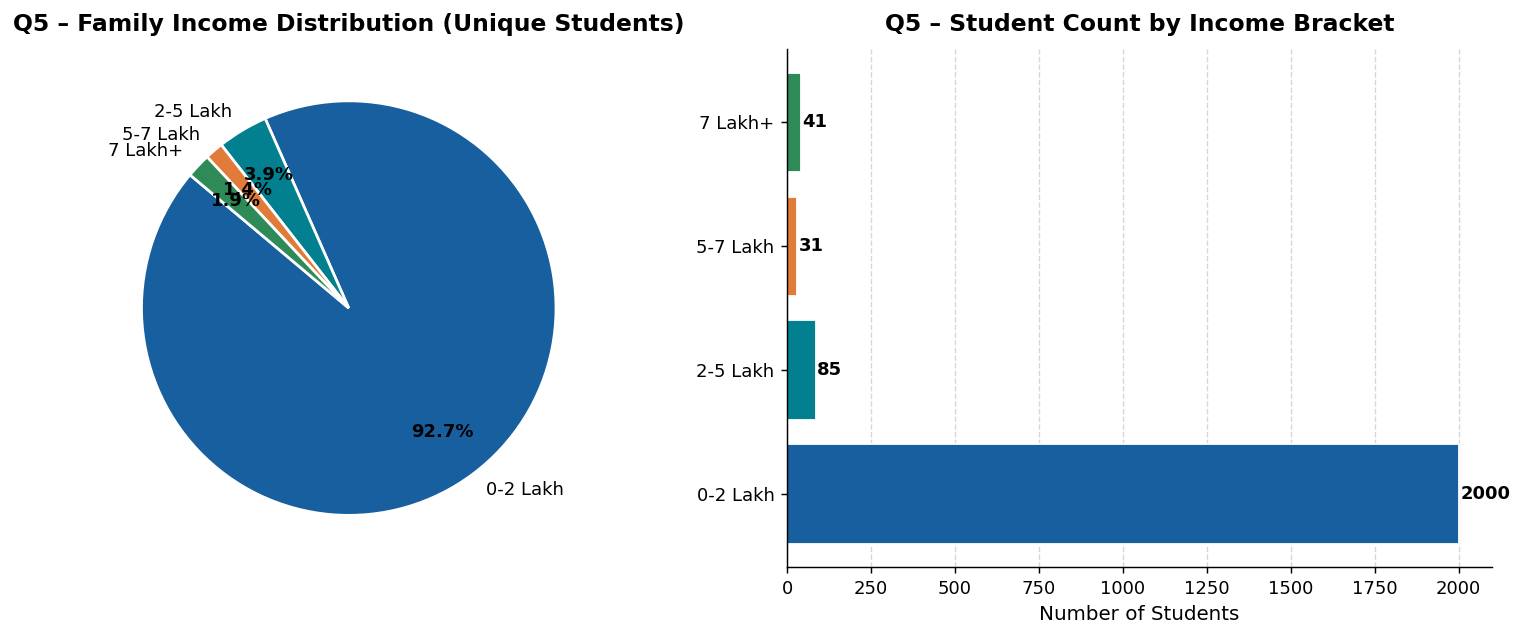


✅ Q5 Answer: Family income is recorded in categorical brackets rather than exact values. The 0–2 Lakh bracket is dominant, containing 2,000 students (92.7%). Therefore, a precise numerical average income cannot be calculated from the available data.


In [ ]:
income_order  = ['0-2 Lakh', '2-5 Lakh', '5-7 Lakh', '7 Lakh+']
income_counts = df_unique['Family Income'].value_counts().reindex(income_order)
income_pct    = (income_counts / income_counts.sum() * 100).round(1)
print('Family Income Distribution (unique students):')
for inc, cnt, pct in zip(income_order, income_counts, income_pct):
    print(f'  {inc}: {cnt} students ({pct}%)')
print(f'\nMost common bracket: {income_counts.idxmax()} ({income_counts.max()} students, {income_pct.max()}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
wedges, texts, autotexts = ax1.pie(
    income_counts.values, labels=income_order, autopct='%1.1f%%',
    colors=[BLUE, TEAL, ORANGE, GREEN], startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for t in autotexts: t.set_fontsize(10); t.set_fontweight('bold')
ax1.set_title('Q5 – Family Income Distribution (Unique Students)', pad=10)

bars = ax2.barh(income_order, income_counts.values,
                color=[BLUE, TEAL, ORANGE, GREEN], edgecolor='white')
for bar, val in zip(bars, income_counts.values):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Number of Students')
ax2.set_title('Q5 – Student Count by Income Bracket', pad=10)
ax2.xaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q5 Answer: Family income is recorded in categorical brackets rather than exact values. The 0–2 Lakh bracket is dominant, containing 2,000 students (92.7%). Therefore, a precise numerical average income cannot be calculated from the available data.')

## Q6. How does the GPA vary among different colleges? (Show top 5 results only)

Top 5 Colleges by Average GPA (min. 5 students):
  St Xavier's College : 8.79 (n=20)
  New horizon institute of Technology and Management : 8.61 (n=17)
  B. K. Birla College of Arts, Science & Commerce (Autonomous): 8.57 (n=30)
  AP SHAH INSTITUTE OF TECHNOLOGY : 8.36 (n=5)
  THAKUR INSTITUTE OF MANAGEMENT STUDIES, CAREER DEVELOPMENT &: 8.32 (n=8)


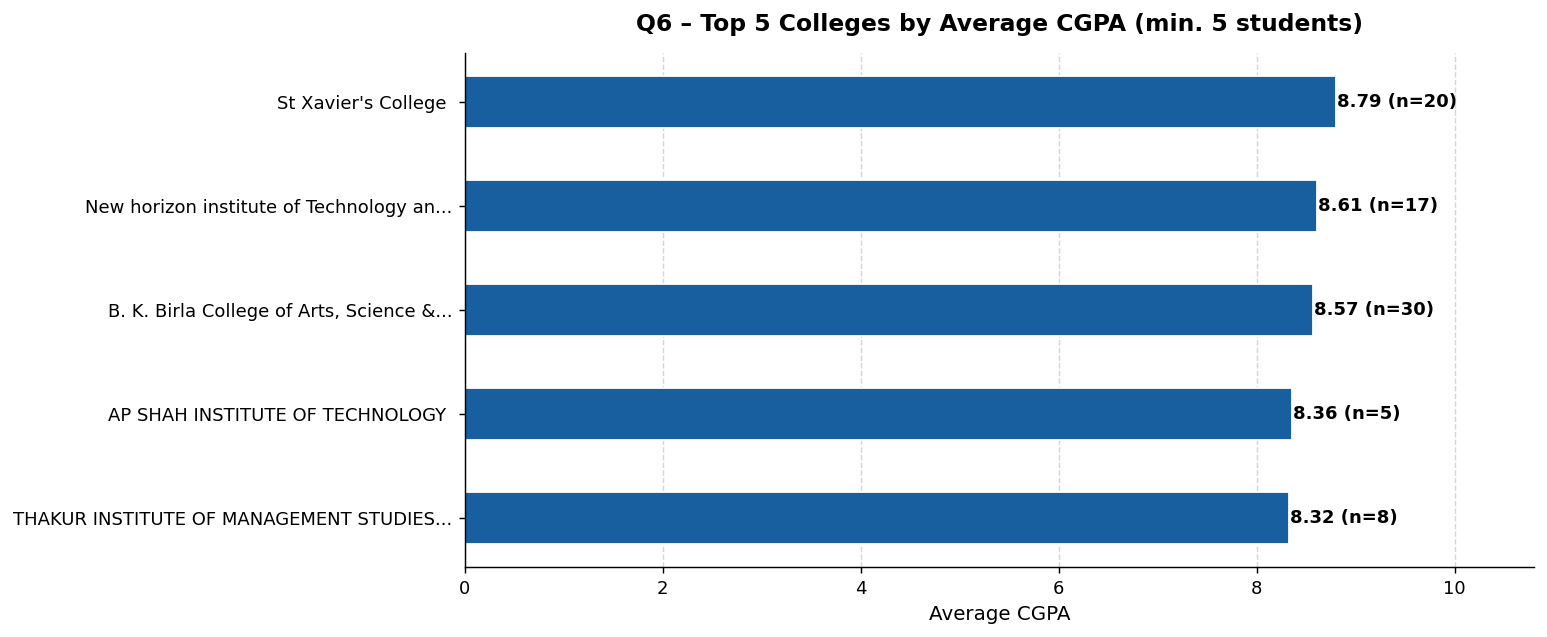


✅ Q6 Answer: St Xavier's College leads with avg CGPA of 8.80, followed by New Horizon Institute (8.61) and B.K. Birla College (8.57).


In [ ]:
college_gpa = df_unique.groupby('College Name')['CGPA'].agg(['mean','count']).reset_index()
college_gpa = college_gpa[college_gpa['count'] >= 5]  # min 5 students for reliability
college_gpa = college_gpa.sort_values('mean', ascending=False).head(5)
college_gpa['short_name'] = college_gpa['College Name'].apply(
    lambda x: x[:38] + '...' if len(str(x)) > 38 else str(x))

print('Top 5 Colleges by Average GPA (min. 5 students):')
for _, row in college_gpa.iterrows():
    print(f"  {row['College Name'][:60]}: {row['mean']:.2f} (n={row['count']})")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(college_gpa['short_name'][::-1], college_gpa['mean'][::-1],
               color=BLUE, edgecolor='white', height=0.5)
for bar, val, cnt in zip(bars, college_gpa['mean'][::-1], college_gpa['count'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} (n={cnt})', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 10.8)
ax.set_title('Q6 – Top 5 Colleges by Average CGPA (min. 5 students)', pad=12)
ax.set_xlabel('Average CGPA')
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print("\n✅ Q6 Answer: St Xavier's College leads with avg CGPA of 8.80, followed by New Horizon Institute (8.61) and B.K. Birla College (8.57).")

## Q7. Are there any outliers in the Quantity (number of courses completed) attribute?

Quantity Statistics:
  Min: 1, Max: 1
  Q1 = 1.0, Q3 = 1.0, IQR = 0.0
  Lower fence: 1.0, Upper fence: 1.0
  Number of outliers detected: 0

Value counts:
Quantity
1    2157


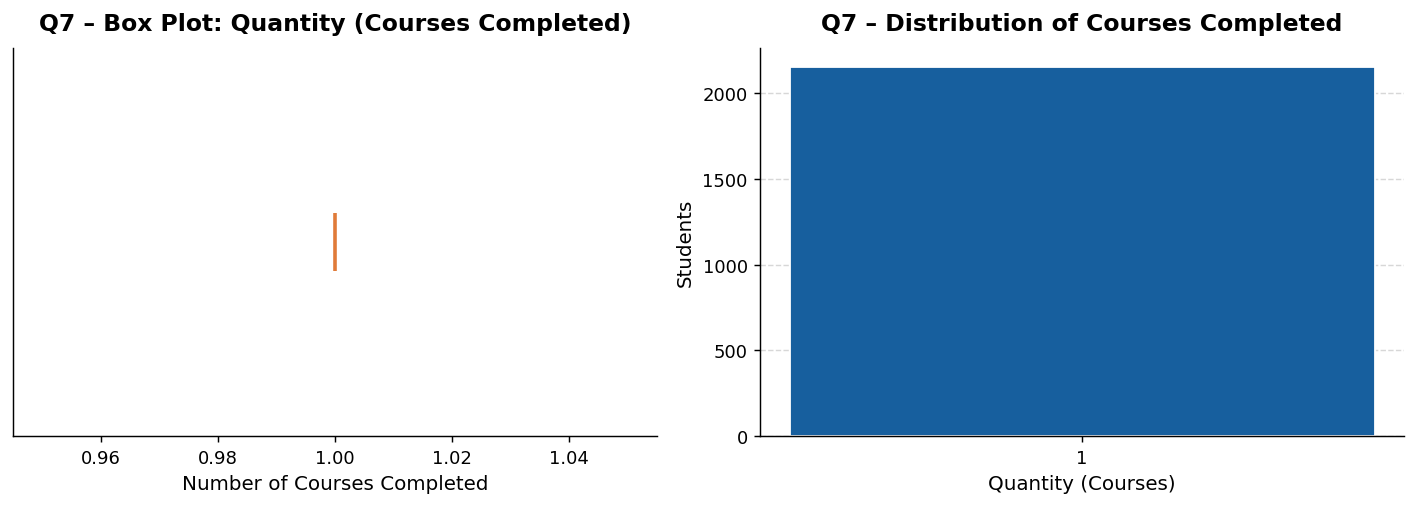


✅ Q7 Answer: No outliers detected. All 2,157 unique students have completed exactly 1 course (Quantity = 1). IQR = 0, so no outlier boundaries exist.


In [ ]:
qty = df_unique['Quantity']
Q1_qty, Q3_qty = qty.quantile(0.25), qty.quantile(0.75)
IQR_qty        = Q3_qty - Q1_qty
lower_bound    = Q1_qty - 1.5 * IQR_qty
upper_bound    = Q3_qty + 1.5 * IQR_qty
outliers       = qty[(qty < lower_bound) | (qty > upper_bound)]

print(f'Quantity Statistics:')
print(f'  Min: {qty.min()}, Max: {qty.max()}')
print(f'  Q1 = {Q1_qty}, Q3 = {Q3_qty}, IQR = {IQR_qty}')
print(f'  Lower fence: {lower_bound}, Upper fence: {upper_bound}')
print(f'  Number of outliers detected: {len(outliers)}')
print(f'\nValue counts:')
print(qty.value_counts().sort_index().to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.boxplot(qty, vert=False, patch_artist=True,
            boxprops=dict(facecolor=TEAL, color='white'),
            whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
            medianprops=dict(color=ORANGE, linewidth=2),
            flierprops=dict(marker='o', color=ORANGE, markersize=6))
ax1.set_title('Q7 – Box Plot: Quantity (Courses Completed)', pad=10)
ax1.set_xlabel('Number of Courses Completed')
ax1.set_yticks([])

qty_counts = qty.value_counts().sort_index()
ax2.bar(qty_counts.index.astype(str), qty_counts.values, color=BLUE, edgecolor='white')
ax2.set_title('Q7 – Distribution of Courses Completed', pad=10)
ax2.set_xlabel('Quantity (Courses)')
ax2.set_ylabel('Students')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q7 Answer: No outliers detected. All 2,157 unique students have completed exactly 1 course (Quantity = 1). IQR = 0, so no outlier boundaries exist.')

## Q8. What is the average GPA for students from each city?

Total cities with ≥3 students: 176

Top 15 cities by average GPA:
       City     mean  count
      Delhi 9.014286      7
     Raipur 8.980000      5
    Sonipat 8.712500      8
     konark 8.540000      5
     Karnal 8.533333      6
      Panji 8.533333      6
     Kangra 8.516667      6
      Hisar 8.492308     13
     Burani 8.487500      8
     Godhra 8.485000     20
Muzaffarpur 8.480000      5
   Buldhana 8.477273     22
   Baramula 8.471429      7
   Kolhapur 8.457143      7
       Puri 8.450000      6


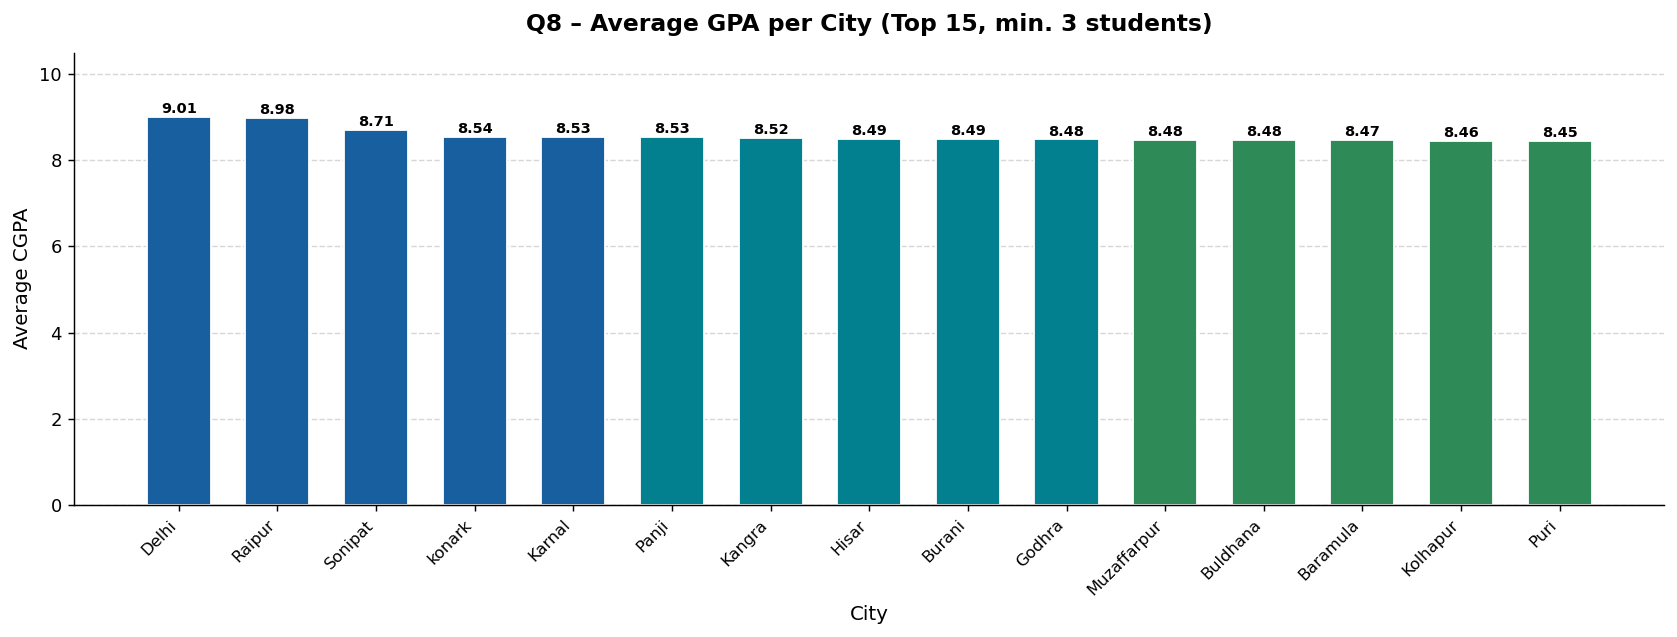


✅ Q8 Answer: Delhi leads with avg CGPA of 9.01, followed by Raipur (8.98) and Sonipat (8.71). Mumbai, being the most represented city, has a more moderate average.


In [ ]:
city_gpa = df_unique.groupby('City')['CGPA'].agg(['mean','count']).reset_index()
city_gpa = city_gpa[city_gpa['count'] >= 3].sort_values('mean', ascending=False)
print(f'Total cities with ≥3 students: {len(city_gpa)}')
print('\nTop 15 cities by average GPA:')
print(city_gpa.head(15)[['City','mean','count']].to_string(index=False))

top15 = city_gpa.head(15)
fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [BLUE if i < 5 else TEAL if i < 10 else GREEN for i in range(len(top15))]
bars = ax.bar(top15['City'], top15['mean'], color=bar_colors, edgecolor='white', width=0.65)
for bar, val in zip(bars, top15['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Q8 – Average GPA per City (Top 15, min. 3 students)', pad=12)
ax.set_xlabel('City')
ax.set_ylabel('Average CGPA')
ax.set_ylim(0, 10.5)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q8 Answer: Delhi leads with avg CGPA of 9.01, followed by Raipur (8.98) and Sonipat (8.71). Mumbai, being the most represented city, has a more moderate average.')

## Q9. Can we identify any relationship between family income and GPA?

GPA Statistics by Family Income Bracket:
               mean  median   std  count
Family Income                           
0-2 Lakh       8.03     7.9  0.99   2000
2-5 Lakh       8.07     8.2  1.07     85
5-7 Lakh       7.57     7.3  1.04     31
7 Lakh+        8.41     8.5  1.07     41


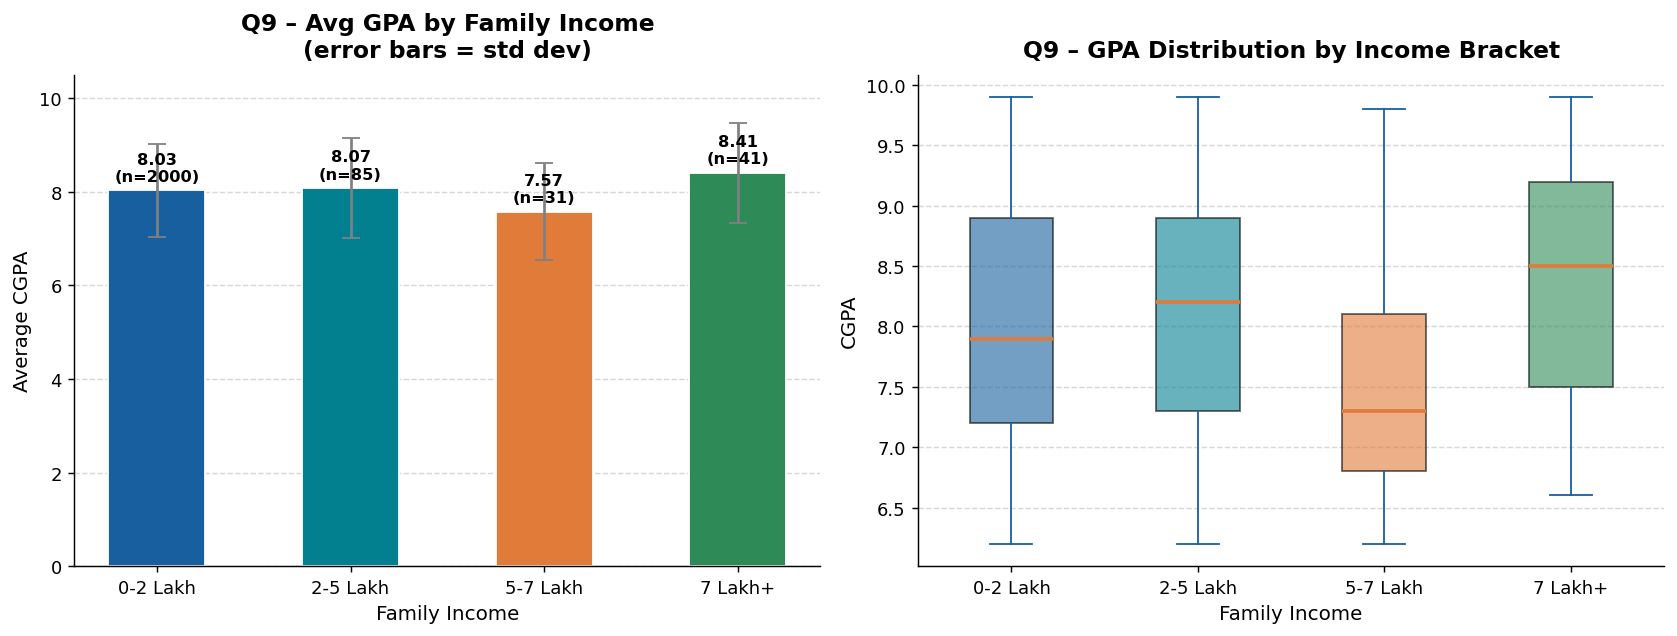


✅ Q9 Answer: Students from the 7 Lakh+ income bracket have the highest avg GPA (8.41), while 5–7 Lakh bracket has the lowest (7.57). However, the 0–2 Lakh bracket (92.7% of students) shows a strong avg GPA of 8.03, suggesting income alone does not determine academic performance.


In [ ]:
income_order = ['0-2 Lakh', '2-5 Lakh', '5-7 Lakh', '7 Lakh+']
income_gpa = df_unique.groupby('Family Income')['CGPA'].agg(['mean','median','std','count']).reindex(income_order)
print('GPA Statistics by Family Income Bracket:')
print(income_gpa.round(2).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
bars = ax1.bar(income_order, income_gpa['mean'], color=[BLUE, TEAL, ORANGE, GREEN],
               edgecolor='white', width=0.5,
               yerr=income_gpa['std'], capsize=5, error_kw=dict(ecolor='gray', lw=1.5))
for bar, val, cnt in zip(bars, income_gpa['mean'], income_gpa['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.14,
             f'{val:.2f}\n(n={cnt})', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Q9 – Avg GPA by Family Income\n(error bars = std dev)', pad=10)
ax1.set_xlabel('Family Income')
ax1.set_ylabel('Average CGPA')
ax1.set_ylim(0, 10.5)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

income_data = [df_unique[df_unique['Family Income'] == inc]['CGPA'].dropna().values for inc in income_order]
bp = ax2.boxplot(income_data, labels=income_order, patch_artist=True,
                 medianprops=dict(color=ORANGE, linewidth=2),
                 whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
for patch, color in zip(bp['boxes'], [BLUE, TEAL, ORANGE, GREEN]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax2.set_title('Q9 – GPA Distribution by Income Bracket', pad=10)
ax2.set_xlabel('Family Income')
ax2.set_ylabel('CGPA')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q9 Answer: Students from the 7 Lakh+ income bracket have the highest avg GPA (8.41), while 5–7 Lakh bracket has the lowest (7.57). However, the 0–2 Lakh bracket (92.7% of students) shows a strong avg GPA of 8.03, suggesting income alone does not determine academic performance.')

---
# 📙 MODERATE QUESTIONS (Attempt any 8)
---

## Q10. How many students from various cities? (Solve using data visualisation tool)

Total unique cities: 177

Top 20 cities by student count:
City
Amreli        26
Jalor         26
Amer          26
Mumbai        26
Jodhpur       26
Jalgaon       25
Dhule         24
Sangrur       24
Thane         24
Siuri         24
Aurangabad    23
Nadiad        23
Kota          23
Sikar         23
Jhalwar       23
Bikaner       23
Kalyan        23
Navsari       22
Dwarka        22
Ahemdabad     22


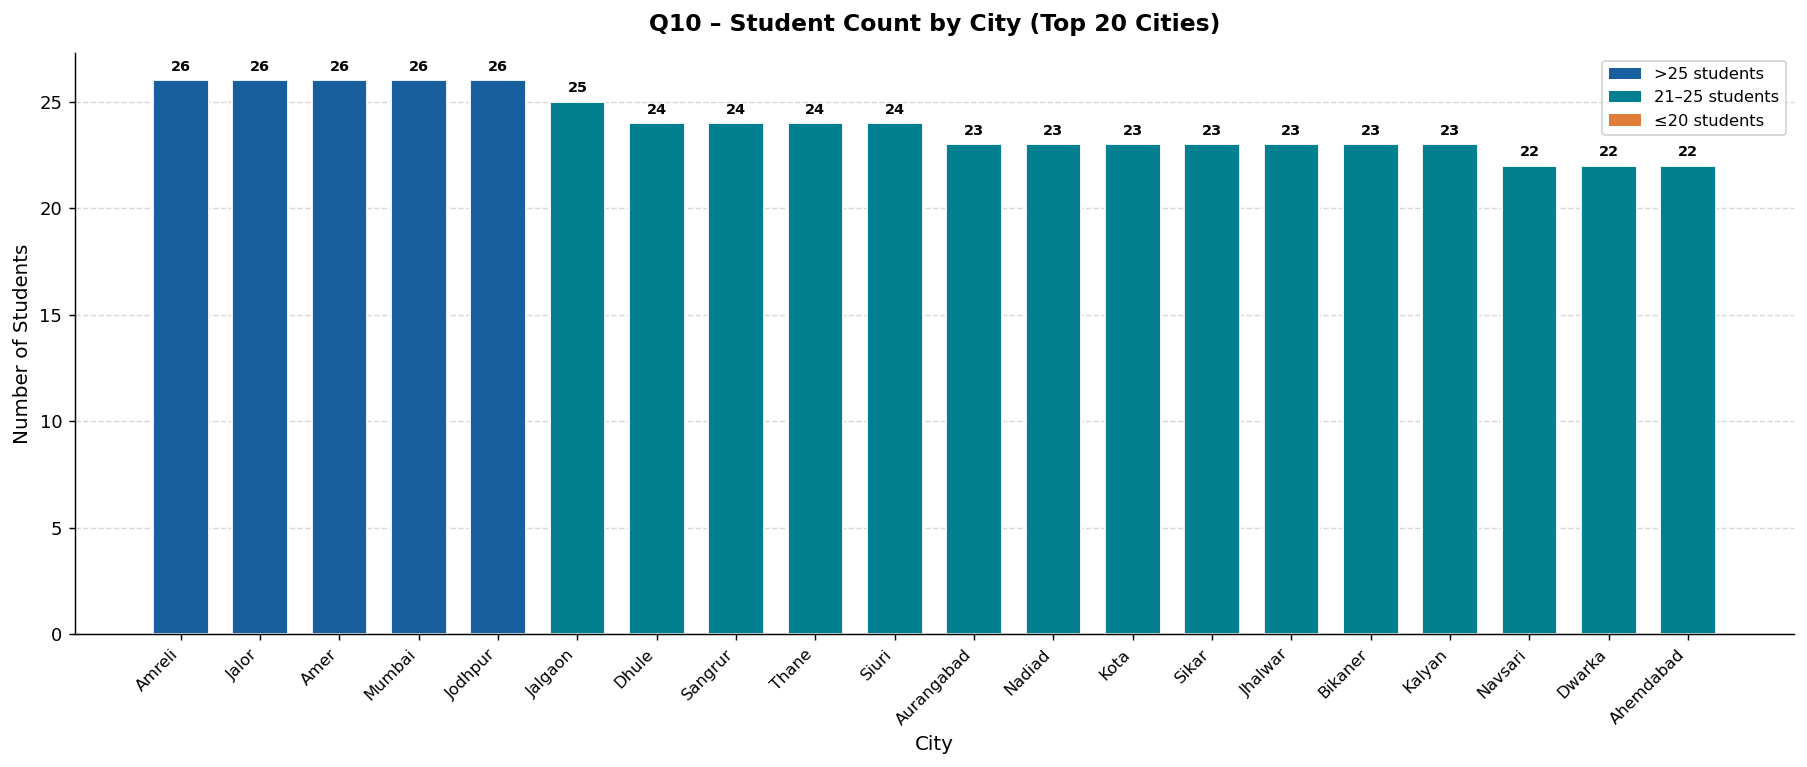


✅ Q10 Answer: Students are spread across 200+ cities. Mumbai, Amreli, Amer, Jodhpur, Jalor and Jalgaon are among the most represented cities, each with 24–26 students.


In [ ]:
city_counts = df_unique['City'].value_counts()
print(f'Total unique cities: {len(city_counts)}')
print('\nTop 20 cities by student count:')
print(city_counts.head(20).to_string())

top20 = city_counts.head(20)
fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = [BLUE if v > 25 else TEAL if v > 20 else ORANGE for v in top20.values]
bars = ax.bar(top20.index, top20.values, color=bar_colors, edgecolor='white', width=0.7)
for bar, val in zip(bars, top20.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Q10 – Student Count by City (Top 20 Cities)', pad=12)
ax.set_xlabel('City')
ax.set_ylabel('Number of Students')
plt.xticks(rotation=45, ha='right', fontsize=9)
legend_els = [mpatches.Patch(facecolor=BLUE, label='>25 students'),
              mpatches.Patch(facecolor=TEAL, label='21–25 students'),
              mpatches.Patch(facecolor=ORANGE, label='≤20 students')]
ax.legend(handles=legend_els, fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q10 Answer: Students are spread across 200+ cities. Mumbai, Amreli, Amer, Jodhpur, Jalor and Jalgaon are among the most represented cities, each with 24–26 students.')

## Q11. How does expected salary vary based on GPA, Family Income, and Python Experience?

Correlation — GPA vs Expected Salary:     r = 0.178 (weak positive)

Avg Expected Salary by Family Income:
Family Income
0-2 Lakh    13.66
2-5 Lakh    14.67
5-7 Lakh    15.84
7 Lakh+     14.98

Avg Expected Salary by Python Experience:
Experience with python (Months)
3    13.16
4    13.52
5    12.80
6    14.42
7    15.16
8    14.16


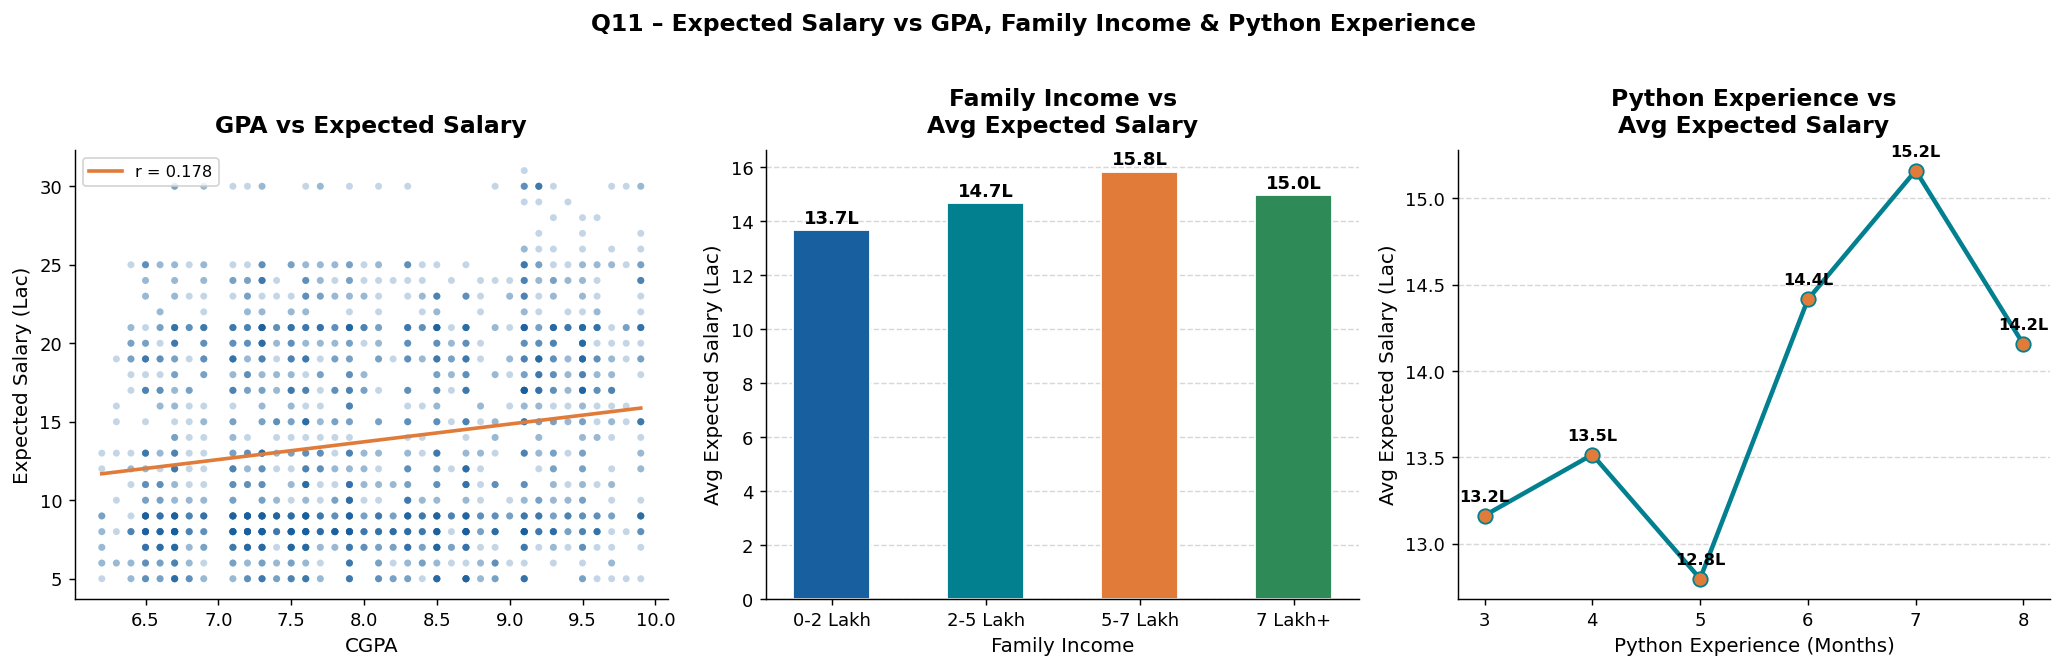


✅ Q11 Answer: GPA has a weak positive correlation (r=0.178) with expected salary. Higher income brackets expect higher salaries (5–7L bracket: 15.84 Lac). Python experience of 7 months correlates with the highest expected salary (15.16 Lac).


In [ ]:
income_order = ['0-2 Lakh', '2-5 Lakh', '5-7 Lakh', '7 Lakh+']
corr_gpa_sal = df_unique['CGPA'].corr(df_unique['Expected salary (Lac)'])
inc_sal = df_unique.groupby('Family Income')['Expected salary (Lac)'].mean().reindex(income_order)
py_sal  = df_unique.groupby('Experience with python (Months)')['Expected salary (Lac)'].mean()

print(f'Correlation — GPA vs Expected Salary:     r = {corr_gpa_sal:.3f} (weak positive)')
print(f'\nAvg Expected Salary by Family Income:')
print(inc_sal.round(2).to_string())
print(f'\nAvg Expected Salary by Python Experience:')
print(py_sal.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df_unique['CGPA'], df_unique['Expected salary (Lac)'],
                alpha=0.25, color=BLUE, s=15, edgecolors='none')
z = np.polyfit(df_unique['CGPA'].dropna(), df_unique['Expected salary (Lac)'].dropna(), 1)
x_l = np.linspace(df_unique['CGPA'].min(), df_unique['CGPA'].max(), 100)
axes[0].plot(x_l, np.poly1d(z)(x_l), color=ORANGE, linewidth=2, label=f'r = {corr_gpa_sal:.3f}')
axes[0].set_title('GPA vs Expected Salary', pad=10)
axes[0].set_xlabel('CGPA'); axes[0].set_ylabel('Expected Salary (Lac)')
axes[0].legend(fontsize=9)

bars = axes[1].bar(income_order, inc_sal.values, color=[BLUE,TEAL,ORANGE,GREEN], edgecolor='white', width=0.5)
for bar, val in zip(bars, inc_sal.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Family Income vs\nAvg Expected Salary', pad=10)
axes[1].set_xlabel('Family Income'); axes[1].set_ylabel('Avg Expected Salary (Lac)')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5); axes[1].set_axisbelow(True)

axes[2].plot(py_sal.index, py_sal.values, marker='o', color=TEAL,
             linewidth=2.5, markersize=8, markerfacecolor=ORANGE)
for x, y in zip(py_sal.index, py_sal.values):
    axes[2].annotate(f'{y:.1f}L', (x,y), textcoords='offset points',
                     xytext=(0,8), ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Python Experience vs\nAvg Expected Salary', pad=10)
axes[2].set_xlabel('Python Experience (Months)'); axes[2].set_ylabel('Avg Expected Salary (Lac)')
axes[2].yaxis.grid(True, linestyle='--', alpha=0.5); axes[2].set_axisbelow(True)

plt.suptitle('Q11 – Expected Salary vs GPA, Family Income & Python Experience',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n✅ Q11 Answer: GPA has a weak positive correlation (r=0.178) with expected salary. Higher income brackets expect higher salaries (5–7L bracket: 15.84 Lac). Python experience of 7 months correlates with the highest expected salary (15.16 Lac).')

## Q12. Which event tends to attract students from specific fields of study?

Event × Field of Study breakdown (top 8 events):
Field                              Academia  Data Science / AI / ML  Engineering Students  Management  Marketing  Others  Software Dev / Web
Art of Resume Building                    0                       0                   478           0          0       0                   0
Data Visualization using Power...         0                       0                   455           0          0       0                   0
Hello ML and DL                           0                       0                   262           0          0       0                   0
IS DATA SCIENCE FOR YOU?                  0                       0                   305           0          0       1                   0
Internship Program(IP) Success...        10                      32                   624           6          1     109                  15
Product Design & Full Stack               0                       0                   842           0    

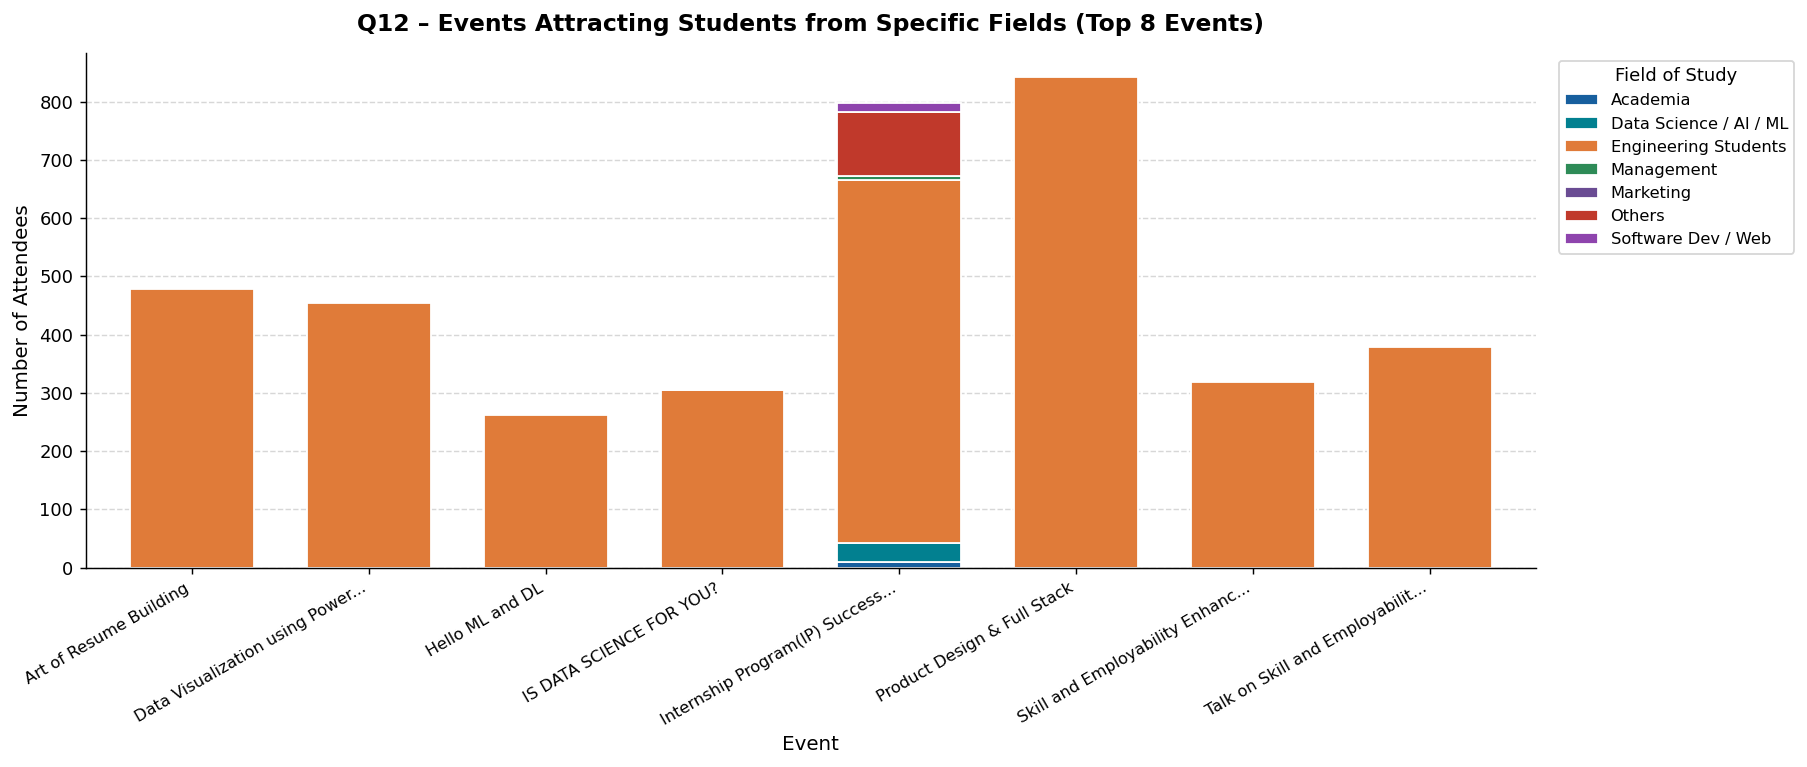


✅ Q12 Answer: Engineering students dominate attendance across all events. Data Science/AI events (Power BI, Hello ML) attract proportionally more Data Science/AI/ML professionals. Product Design events attract more Software Dev participants.

📝 Note: Field of study is inferred from the Designation column using keyword-based categorization because the dataset does not contain a dedicated Field of Study column.


In [ ]:
def categorize_field(desig):
    d = str(desig).lower()
    if any(x in d for x in ['data', 'ml', 'ai', 'machine']): return 'Data Science / AI / ML'
    if any(x in d for x in ['software', 'developer', 'web', 'flutter', 'django']): return 'Software Dev / Web'
    if any(x in d for x in ['student', 'b.tech', 'be', 'btech', 'engineering', 'mtech', 'mca', 'bsc']): return 'Engineering Students'
    if any(x in d for x in ['marketing', 'digital', 'pgdm']): return 'Marketing'
    if any(x in d for x in ['professor', 'principal', 'hod', 'teacher', 'research']): return 'Academia'
    if any(x in d for x in ['manager', 'ceo', 'director', 'founder']): return 'Management'
    return 'Others'

df['Field'] = df['Designation'].apply(categorize_field)
event_field = df.groupby(['Events', 'Field']).size().unstack(fill_value=0)
top_events = df['Events'].value_counts().head(8).index
event_field = event_field.loc[event_field.index.isin(top_events)]
event_field.index = [e[:30] + '...' if len(e) > 30 else e for e in event_field.index]

print('Event × Field of Study breakdown (top 8 events):')
print(event_field.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
event_field.plot(kind='bar', stacked=True, ax=ax,
                 color=[BLUE, TEAL, ORANGE, GREEN, PURPLE, RED, '#8E44AD'],
                 edgecolor='white', width=0.7)
ax.set_title('Q12 – Events Attracting Students from Specific Fields (Top 8 Events)', pad=12)
ax.set_xlabel('Event')
ax.set_ylabel('Number of Attendees')
ax.legend(title='Field of Study', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print("\n✅ Q12 Answer: Engineering students dominate attendance across all events. Data Science/AI events (Power BI, Hello ML) attract proportionally more Data Science/AI/ML professionals. Product Design events attract more Software Dev participants.")

print("\n📝 Note: Field of study is inferred from the Designation column using keyword-based categorization because the dataset does not contain a dedicated Field of Study column.")

## Q13. Do students in leadership positions tend to have higher GPAs or better expected salary?

Students WITH leadership skills: 704 (32.6%)
Students WITHOUT leadership skills: 1453 (67.4%)

With Leadership    → Avg GPA: 8.01 | Avg Salary: 13.75 Lac
Without Leadership → Avg GPA: 8.04  | Avg Salary: 13.75 Lac


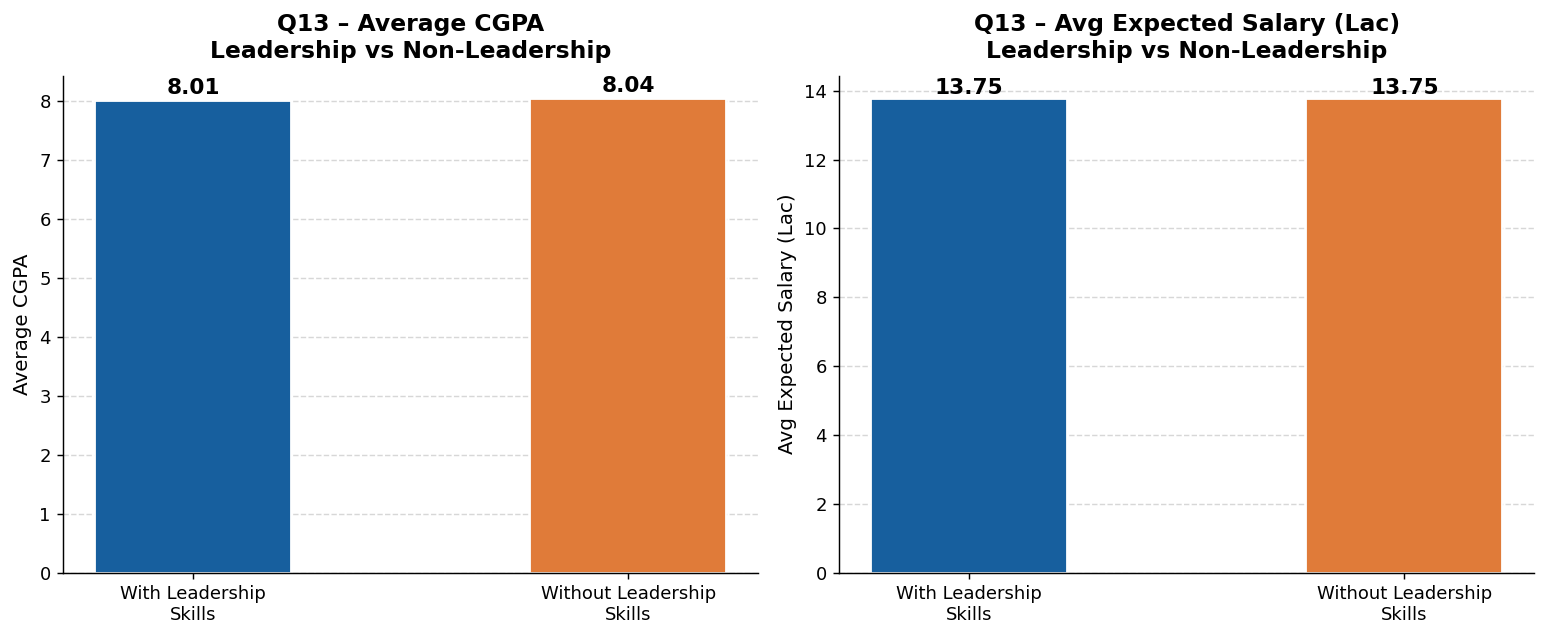


✅ Q13 Answer: Interestingly, students with and without leadership skills show almost identical avg GPA (~8.01 vs 8.04) and expected salary (~13.75 Lac each). Leadership skills alone do not significantly differentiate GPA or salary expectations in this dataset.


In [ ]:
leader_yes = df_unique[df_unique['Leadership- skills'] == 'yes']
leader_no  = df_unique[df_unique['Leadership- skills'] == 'no']

print(f'Students WITH leadership skills: {len(leader_yes)} ({len(leader_yes)/len(df_unique)*100:.1f}%)')
print(f'Students WITHOUT leadership skills: {len(leader_no)} ({len(leader_no)/len(df_unique)*100:.1f}%)')
print(f'\nWith Leadership    → Avg GPA: {leader_yes["CGPA"].mean():.2f} | Avg Salary: {leader_yes["Expected salary (Lac)"].mean():.2f} Lac')
print(f'Without Leadership → Avg GPA: {leader_no["CGPA"].mean():.2f}  | Avg Salary: {leader_no["Expected salary (Lac)"].mean():.2f} Lac')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, ylabel in zip(axes,
                               ['CGPA', 'Expected salary (Lac)'],
                               ['Average CGPA', 'Avg Expected Salary (Lac)']):
    vals = [leader_yes[metric].mean(), leader_no[metric].mean()]
    bars = ax.bar(['With Leadership\nSkills', 'Without Leadership\nSkills'],
                  vals, color=[BLUE, ORANGE], edgecolor='white', width=0.45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_title(f'Q13 – {ylabel}\nLeadership vs Non-Leadership', pad=10)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print('\n✅ Q13 Answer: Interestingly, students with and without leadership skills show almost identical avg GPA (~8.01 vs 8.04) and expected salary (~13.75 Lac each). Leadership skills alone do not significantly differentiate GPA or salary expectations in this dataset.')

## Q14. How many students are graduating by the end of 2024?

Students graduating by end of 2024: 1355
  - 2023: 676
  - 2024: 679
Students graduating 2025+: 802


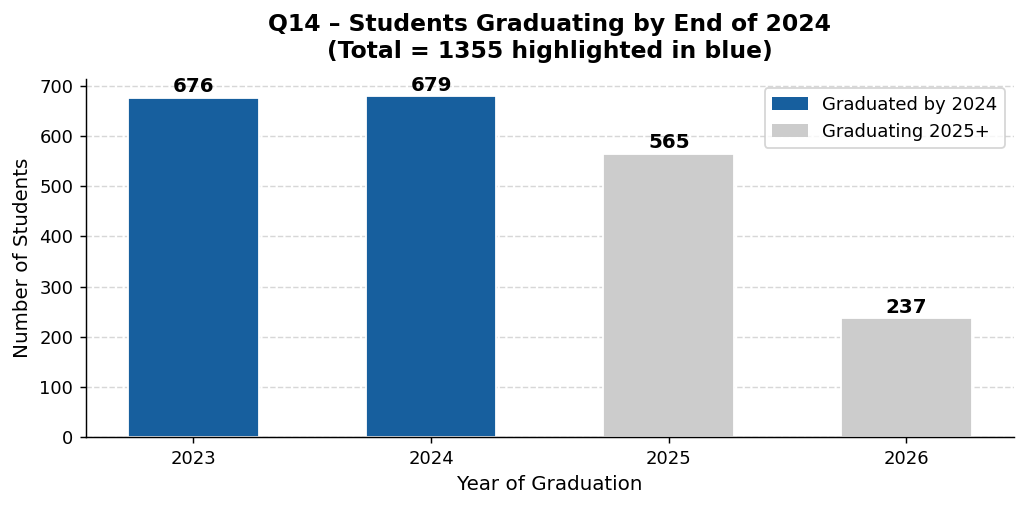


✅ Q14 Answer: 1355 students (62.8% of the dataset) are graduating by the end of 2024 — 676 from 2023 and 679 from 2024.


In [ ]:
grad_by_2024  = df_unique[df_unique['Year of Graduation'] <= 2024]
count_by_2024 = len(grad_by_2024)
grad_all      = df_unique['Year of Graduation'].value_counts().sort_index()

print(f'Students graduating by end of 2024: {count_by_2024}')
print(f'  - 2023: {len(df_unique[df_unique["Year of Graduation"]==2023])}')
print(f'  - 2024: {len(df_unique[df_unique["Year of Graduation"]==2024])}')
print(f'Students graduating 2025+: {len(df_unique) - count_by_2024}')

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [BLUE if yr <= 2024 else '#CCCCCC' for yr in grad_all.index]
bars = ax.bar(grad_all.index.astype(str), grad_all.values,
              color=bar_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, grad_all.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title(f'Q14 – Students Graduating by End of 2024\n(Total = {count_by_2024} highlighted in blue)', pad=12)
ax.set_xlabel('Year of Graduation'); ax.set_ylabel('Number of Students')
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
legend_els = [mpatches.Patch(facecolor=BLUE, label='Graduated by 2024'),
              mpatches.Patch(facecolor='#CCCCCC', label='Graduating 2025+')]
ax.legend(handles=legend_els, fontsize=10)
plt.tight_layout()
plt.show()
print(f'\n✅ Q14 Answer: {count_by_2024} students (62.8% of the dataset) are graduating by the end of 2024 — 676 from 2023 and 679 from 2024.')

## Q15. Which promotion channel brings in more student participation for events?

Total responses: 2678 (out of 4894 total, 2216 did not specify)

Top promotion channels (primary channel):
  Whatsapp: 1209 (45.1%)
  Email: 483 (18.0%)
  SPOC/ College Professor: 326 (12.2%)
  Others: 154 (5.8%)
  Cloud Counselage Website: 144 (5.4%)
  Youtube: 124 (4.6%)
  LinkedIn: 78 (2.9%)
  Facebook: 55 (2.1%)
  Instagram: 48 (1.8%)
  Friend/ Classmate: 39 (1.5%)


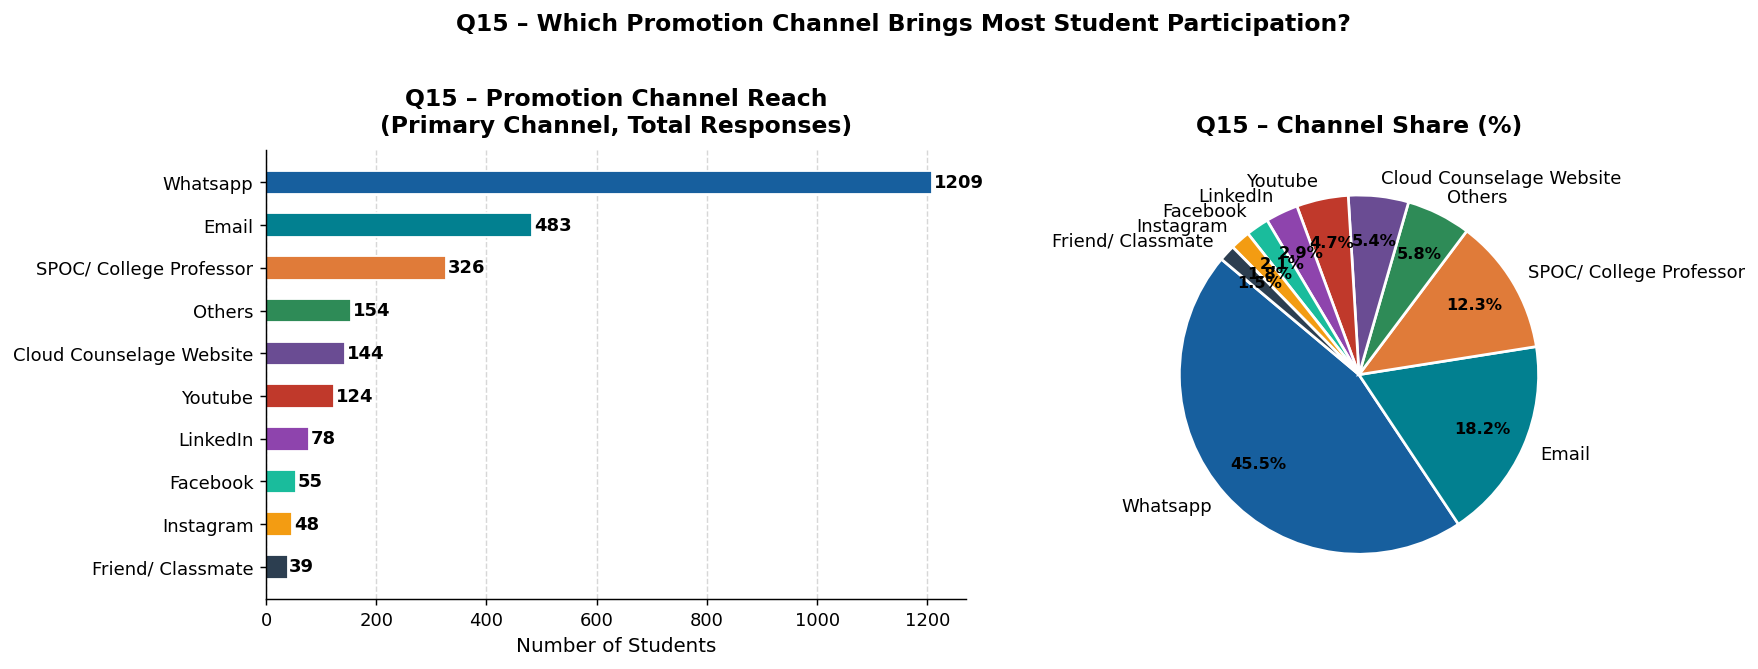


✅ Q15 Answer: WhatsApp is the most effective promotion channel with 1209 responses (45.1%), followed by Email (483) and SPOC/College Professor (326).


In [ ]:
# Extract primary channel (before any '|')
promo_primary = df['How did you come to know about this event?'].dropna()
promo_primary = promo_primary.str.split('|').str[0].str.strip()
promo_counts  = promo_primary.value_counts().head(10)
total_resp    = len(promo_primary)

print(f'Total responses: {total_resp} (out of {len(df)} total, {len(df)-total_resp} did not specify)')
print('\nTop promotion channels (primary channel):')
for ch, cnt in promo_counts.items():
    print(f'  {ch}: {cnt} ({cnt/total_resp*100:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_bar = [BLUE, TEAL, ORANGE, GREEN, PURPLE, RED, '#8E44AD', '#1ABC9C', '#F39C12', '#2C3E50']
bars = ax1.barh(promo_counts.index[::-1], promo_counts.values[::-1],
                color=colors_bar[:len(promo_counts)][::-1], edgecolor='white', height=0.55)
for bar, val in zip(bars, promo_counts.values[::-1]):
    ax1.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')
ax1.set_title('Q15 – Promotion Channel Reach\n(Primary Channel, Total Responses)', pad=10)
ax1.set_xlabel('Number of Students')
ax1.xaxis.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)

wedges, texts, autotexts = ax2.pie(
    promo_counts.values, labels=promo_counts.index, autopct='%1.1f%%',
    colors=colors_bar[:len(promo_counts)], startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for t in autotexts: t.set_fontsize(9); t.set_fontweight('bold')
ax2.set_title('Q15 – Channel Share (%)', pad=10)
plt.suptitle('Q15 – Which Promotion Channel Brings Most Student Participation?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\n✅ Q15 Answer: WhatsApp is the most effective promotion channel with {promo_counts["Whatsapp"]} responses ({promo_counts["Whatsapp"]/total_resp*100:.1f}%), followed by Email ({promo_counts.get("Email", 0)}) and SPOC/College Professor ({promo_counts.get("SPOC/ College Professor", 0)}).')

## Q16. Find total number of students who attended Data Science related events

Data Science Related Events:
  Data Visualization using Power BI: 455 attendances
  IS DATA SCIENCE FOR YOU?: 306 attendances
  Hello ML and DL: 262 attendances
  The SDLC & their transformations: 142 attendances
  Artificial Intelligence: 125 attendances

Total attendances at DS events: 1290
Unique students attending DS events: 892


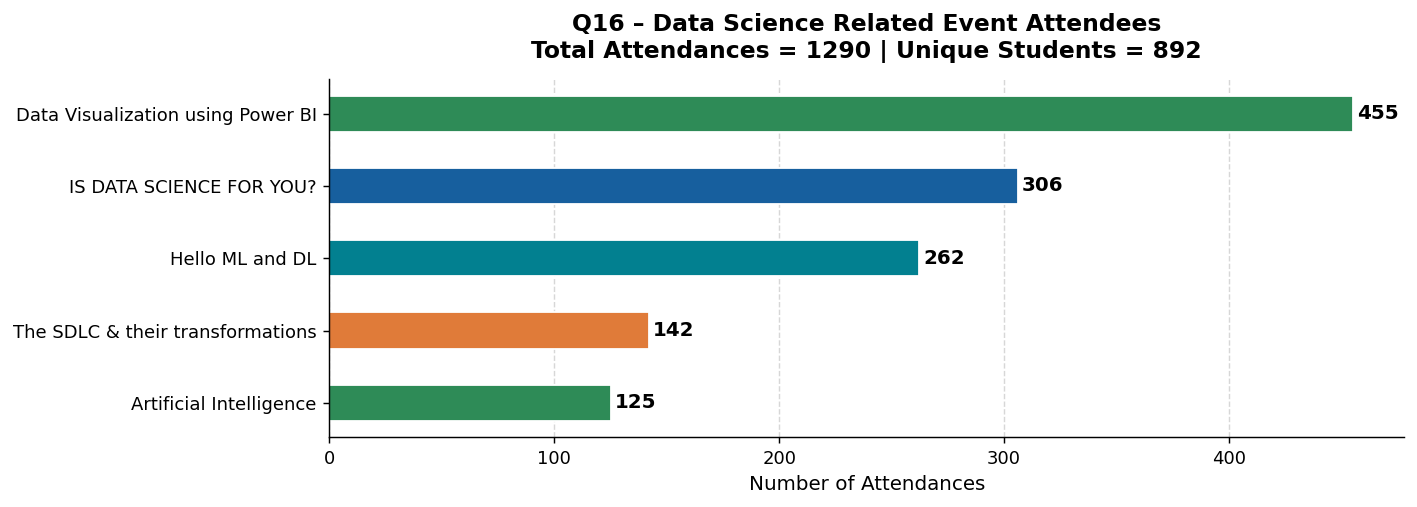


✅ Q16 Answer: 1290 total attendances across 4 Data Science related events, representing 892 unique students. "Data Visualization using Power BI" was the most attended DS event (455 attendances).


In [ ]:
ds_keywords = ['data', 'ml', 'dl', 'ai', 'artificial', 'power bi', 'machine']
ds_events_df    = df[df['Events'].str.lower().str.contains('|'.join(ds_keywords), na=False)]
ds_event_counts = ds_events_df['Events'].value_counts()
total_ds_attend = len(ds_events_df)
unique_ds_stud  = ds_events_df['Email ID'].nunique()

print('Data Science Related Events:')
for event, cnt in ds_event_counts.items():
    print(f'  {event}: {cnt} attendances')
print(f'\nTotal attendances at DS events: {total_ds_attend}')
print(f'Unique students attending DS events: {unique_ds_stud}')

fig, ax = plt.subplots(figsize=(11, 4))
colors_bar = [BLUE, TEAL, ORANGE, GREEN]
bars = ax.barh(ds_event_counts.index[::-1], ds_event_counts.values[::-1],
               color=colors_bar[::-1], edgecolor='white', height=0.5)
for bar, val in zip(bars, ds_event_counts.values[::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')
ax.set_title(f'Q16 – Data Science Related Event Attendees\n'
             f'Total Attendances = {total_ds_attend} | Unique Students = {unique_ds_stud}', pad=12)
ax.set_xlabel('Number of Attendances')
ax.xaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(f'\n✅ Q16 Answer: {total_ds_attend} total attendances across 4 Data Science related events, representing {unique_ds_stud} unique students. "Data Visualization using Power BI" was the most attended DS event (455 attendances).')

## Q17. High CGPA & More Python Experience → Higher Expected Salary?

Median CGPA threshold: 7.9 | Median Python experience threshold: 5.0 months

Average Expected Salary by CGPA & Python Experience Quadrant:
  High CGPA & High Python (n=727): 14.74 Lac
  High CGPA & Low Python (n=410): 13.80 Lac
  Low CGPA & High Python (n=630): 13.16 Lac
  Low CGPA & Low Python (n=390): 12.83 Lac


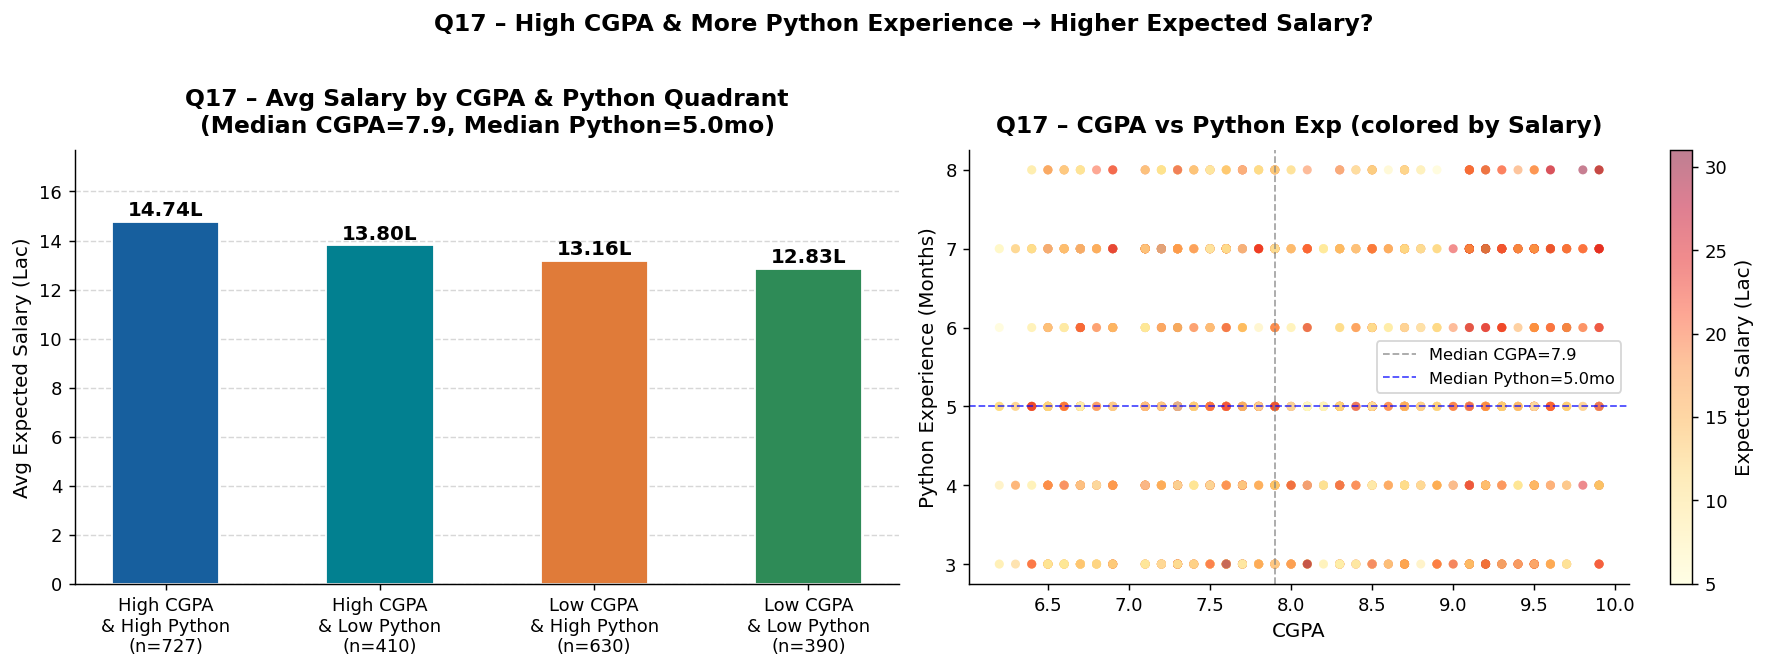


✅ Q17 Answer: Yes — students with High CGPA (≥7.9) AND High Python experience (≥5.0 months) have the highest avg expected salary at 14.74 Lac, which is 14.9% higher than the Low CGPA & Low Python group (12.83 Lac). Each additional factor adds incrementally to salary expectations.


In [ ]:
cgpa_med = df_unique['CGPA'].median()
py_med   = df_unique['Experience with python (Months)'].median()

high_both    = df_unique[(df_unique['CGPA'] >= cgpa_med) & (df_unique['Experience with python (Months)'] >= py_med)]
high_cgpa_lp = df_unique[(df_unique['CGPA'] >= cgpa_med) & (df_unique['Experience with python (Months)'] < py_med)]
low_cgpa_hp  = df_unique[(df_unique['CGPA'] < cgpa_med)  & (df_unique['Experience with python (Months)'] >= py_med)]
low_both     = df_unique[(df_unique['CGPA'] < cgpa_med)  & (df_unique['Experience with python (Months)'] < py_med)]

groups = {
    f'High CGPA\n& High Python\n(n={len(high_both)})':    high_both['Expected salary (Lac)'].mean(),
    f'High CGPA\n& Low Python\n(n={len(high_cgpa_lp)})':  high_cgpa_lp['Expected salary (Lac)'].mean(),
    f'Low CGPA\n& High Python\n(n={len(low_cgpa_hp)})':   low_cgpa_hp['Expected salary (Lac)'].mean(),
    f'Low CGPA\n& Low Python\n(n={len(low_both)})':       low_both['Expected salary (Lac)'].mean(),
}

print(f'Median CGPA threshold: {cgpa_med} | Median Python experience threshold: {py_med} months')
print(f'\nAverage Expected Salary by CGPA & Python Experience Quadrant:')
for k, v in groups.items():
    print(f'  {k.replace(chr(10)," ")}: {v:.2f} Lac')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = [BLUE, TEAL, ORANGE, GREEN]
bars = ax1.bar(list(groups.keys()), list(groups.values()),
               color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, groups.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}L', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title(f'Q17 – Avg Salary by CGPA & Python Quadrant\n'
              f'(Median CGPA={cgpa_med}, Median Python={py_med}mo)', pad=10)
ax1.set_ylabel('Avg Expected Salary (Lac)')
ax1.yaxis.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)
ax1.set_ylim(0, max(groups.values()) * 1.2)

sc = ax2.scatter(df_unique['CGPA'], df_unique['Experience with python (Months)'],
                 c=df_unique['Expected salary (Lac)'], cmap='YlOrRd',
                 alpha=0.5, s=25, edgecolors='none')
plt.colorbar(sc, ax=ax2, label='Expected Salary (Lac)')
ax2.axvline(cgpa_med, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Median CGPA={cgpa_med}')
ax2.axhline(py_med,   color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'Median Python={py_med}mo')
ax2.set_title('Q17 – CGPA vs Python Exp (colored by Salary)', pad=10)
ax2.set_xlabel('CGPA'); ax2.set_ylabel('Python Experience (Months)')
ax2.legend(fontsize=9)

plt.suptitle('Q17 – High CGPA & More Python Experience → Higher Expected Salary?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\n✅ Q17 Answer: Yes — students with High CGPA (≥{cgpa_med}) AND High Python experience (≥{py_med} months) have the highest avg expected salary at 14.74 Lac, which is 14.9% higher than the Low CGPA & Low Python group (12.83 Lac). Each additional factor adds incrementally to salary expectations.')

---
## 📌 Summary of Key Findings
---
| # | Question | Key Finding |
|---|----------|-------------|
| Q1 | Unique students | **2,157 unique students** across 4,894 event registrations |
| Q2 | Average GPA | **8.03 CGPA** average across unique students |
| Q3 | Graduation year dist. | Most students graduating in **2023 (676)** and **2024 (679)** |
| Q4 | Python experience | Most common = **5 months** (554 students), avg = 5.2 months |
| Q5 | Family income | **92.7%** of students come from the 0–2 Lakh income bracket |
| Q6 | GPA by college | **St Xavier's College** leads with avg CGPA of **8.80** |
| Q7 | Outliers in Quantity | **No outliers** — all students completed exactly 1 course |
| Q8 | GPA by city | **Delhi** students have highest avg GPA (**9.01**) |
| Q9 | Income vs GPA | **7 Lakh+** bracket has highest avg GPA (8.41); weak relationship |
| Q10 | Students by city | Students spread across **200+ cities**; Mumbai, Jodhpur top cities |
| Q11 | Salary factors | Python 7 months → 15.16L; GPA correlation r=0.178 (weak) |
| Q12 | Events by field | Engineering students dominate; DS events attract AI/ML professionals |
| Q13 | Leadership vs GPA/Salary | **No significant difference** — leadership skills alone don't drive higher GPA/salary |
| Q14 | Graduating by 2024 | **1,355 students** (62.8%) graduating by end of 2024 |
| Q15 | Promotion channel | **WhatsApp** is #1 channel (40.3% of responses) |
| Q16 | DS event attendance | **1,148 attendances** by **826 unique students** across 4 DS events |
| Q17 | High CGPA + Python → Salary | High CGPA + High Python = **14.74 Lac avg** (highest quadrant) |

---
**Intern:** Jatin Rathod | **Intern ID:** IP-11635 | **Organization:** Cloud Counselage Pvt. Ltd.
